In [1]:
# IPython magig  tools
%load_ext autoreload
%autoreload 2

from aind_vr_foraging_analysis.utils.parsing import data_access

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

sns.set_context('talk')

import warnings
pd.options.mode.chained_assignment = None  # Ignore SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

color1='#d95f02'
color2='#1b9e77'
color3='#7570b3'
color4='yellow'
odor_list_color = [color1, color2, color3, color4]

pdf_path = r'Z:\scratch\vr-foraging\sessions'
results_path = r'C:\Users\tiffany.ona\OneDrive - Allen Institute\Documents\VR foraging\experiments\batch 8 - reversals\results'

color_dict_label = {'InterSite': '#808080',
    'InterPatch': '#b3b3b3', 
    'PatchZ': '#d95f02', 'PatchZB': '#d95f02', 
    'PatchB': '#d95f02','PatchA': '#7570b3', 
    'PatchC': '#1b9e77',
    'Alpha-pinene': '#1b9e77', 
    'Methyl Butyrate': '#7570b3', 
    'Amyl Acetate': '#d95f02', 
    'Fenchone': '#7570b3', 
     'S': color1,
    'D': color2,
    'N': color3,   
    }

label_dict = {**{
"InterSite": '#808080',
"InterPatch": '#b3b3b3'}, 
            **color_dict_label}
import os


In [2]:
# Function to assign codes
def get_condition_code(text):
    if 'delayed' in text:
        return 'D'
    elif 'single' in text:
        return 'S'
    elif 'no_reward' in text or 'noreward' in text  or 'null' in text:
        return 'N'
    else:
        return None

In [3]:
trainer_dict = {
                '846440': 'Olivia',
                '846441': 'Olivia',
                '846439': 'Olivia',
                '849495': 'Alex',
                '863680': 'Alex',
                '863700': 'Alex',
                '863704': 'Alex',
                '863696': 'Alex',
                "863698": 'Alex',
                "866064": 'Alex',
                "864848": 'Alex',
                "864847": 'Alex',
                }
mouse_list = trainer_dict.keys()

In [4]:
date_string = "2026-6-01"

sum_df = pd.DataFrame()
summary_df = pd.DataFrame()
for mouse in mouse_list:
    session_paths = data_access.find_sessions_relative_to_date(
        mouse=mouse,
        date_string=date_string,
        when='on_or_after'
    )
    session_n = 0
    for session_path in session_paths:
        print(mouse, session_path)
        try:
            all_epochs, stream_data, data = data_access.load_session(
                session_path
            )
        except:
            print(f"Error loading {session_path.name}")
            continue
        all_epochs['mouse'] = mouse
        all_epochs['session'] = session_path.name[7:17]
        all_epochs['session_n'] = session_n
        all_epochs['stage'] = data['config'].streams.tasklogic_input.data['stage_name']
        
        if all_epochs['stage'].iloc[0] in ['one_odor_no_depletion', 'one_odor_w_depletion_day_0', 'one_odor_w_depletion_day_1', "all_odors_rewarded"]:
            print(f"Skipping {session_path.name} due to stage {all_epochs['stage'].iloc[0]}")
            continue
        
        last_engaged_patch = all_epochs['patch_number'][all_epochs['skipped_count'] >= 10].min()
        if pd.isna(last_engaged_patch):
            last_engaged_patch = all_epochs['patch_number'].max()
        all_epochs['engaged'] = np.where(all_epochs['patch_number'] <= last_engaged_patch - 10 , 1, 0)

        all_epochs = all_epochs[all_epochs['engaged'] == 1]
        
        try:
            all_epochs['block'] = all_epochs['patch_label'].str.extract(r'set(\d+)').astype(int)
        except ValueError: 
            all_epochs['block'] = 0
            
        print(all_epochs.patch_label.unique())
        # Compute total and visited patches in a single step
        all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)
        
        all_epochs['group'] = all_epochs['stage'].str.split('_').str[1]
        all_epochs['group'] = np.where(all_epochs['group'] == 'capped', 'fixed', all_epochs['group'])
        
        patch_total = all_epochs.groupby('patch_label')['patch_number'].nunique()

        visited_filter = (all_epochs.site_number == 0) & (all_epochs.is_choice == 1)
        patch_visited = all_epochs.loc[visited_filter].groupby('patch_label')['patch_number'].nunique()
        block = all_epochs.loc[visited_filter].groupby('patch_label')['block'].nunique()

        # Combine into one dataframe
        patch_df = pd.DataFrame({
            'patch_number': patch_total,
            'visited': patch_visited, 
            'block': block
        }).fillna(0)  # Fill NaNs for labels that were never visited

        patch_df['fraction_visited'] = patch_df['visited'] / patch_df['patch_number']
        patch_df['mouse'] = mouse
        patch_df['session'] = session_path.name[7:17]
        
        sum_df = pd.concat([patch_df.reset_index(), sum_df])
        summary_df = pd.concat([all_epochs, summary_df])


846440 Z:\stage\vr-foraging\data\846440\846440_2026-06-01T194858Z
{'harp_behavior': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-06-01T194858Z\behavior\Behavior.harp, 'harp_olfactometer': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-06-01T194858Z\behavior\Olfactometer.harp, 'harp_lickometer': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-06-01T194858Z\behavior\Lickometer.harp, 'harp_sniffsensor': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-06-01T194858Z\behavior\SniffDetector.harp, 'harp_stepperdriver': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-06-01T194858Z\behavior\StepperDriver.harp, 'harp_clock': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-06-01T194858Z\behavior\ClockGenerator.harp, 'harp_treadmill': DataStreamSource from Z:\stage\vr-foraging\data\846440\846440_2026-06-01T194858Z\behavior\Treadmill.harp, 'harp_environment_sensor': DataStreamSource 

: 

: 

In [ ]:
# Convert to datetime if not already
sum_df['session'] = pd.to_datetime(sum_df['session'])
summary_df['session'] = pd.to_datetime(summary_df['session'])

# Create session numbers by mapping unique dates to integers
sum_df['session_n'] = sum_df['session'].astype(str).map({date: i for i, date in enumerate(sorted(sum_df['session'].unique()))})
summary_df['session_n'] = summary_df['session'].astype(str).map({date: i for i, date in enumerate(sorted(summary_df['session'].unique()))})

summary_df = summary_df.loc[summary_df.engaged == 1]
summary_df.sort_values(by=['mouse', 'session'], inplace=True)
sum_df.sort_values(by=['mouse', 'session'], inplace=True)

In [ ]:
summary_df['is_reversal'] = summary_df['stage'].str.contains('reversal', case=False, na=False)

In [ ]:
sessions_per_mouse = summary_df.groupby(["mouse", "session"]).is_reversal.any()
counts_per_mouse = sessions_per_mouse.groupby("mouse").sum()
print(counts_per_mouse)

mouse
846439    17
846440    16
846441    17
849495    18
863680    18
863696    18
863698    11
863700    18
863703     0
863704    17
864847    10
864848    10
866064    10
Name: is_reversal, dtype: int64


In [ ]:
session_flags = summary_df.groupby(["mouse", "session"]).is_reversal.any()
num_sessions_with_reversal = session_flags.sum()
print(f"Total sessions with reversal: {num_sessions_with_reversal}")

Total sessions with reversal: 180


In [6]:
odor = summary_df[summary_df['label'] == 'OdorSite'].copy()

visit_keys = ['mouse', 'session', 'patch_number', 'patch_label']

# Actual stops = max site_number + 1 per visit
actual = (odor.groupby(visit_keys)['site_number'].max()).rename('actual_stops')

def get_optimal(visit_df):
    label = visit_df['patch_label'].iloc[0]
    group = visit_df['group'].iloc[0]
    if label == 'S':
        return 1
    elif label == 'N':
        return 0
    elif label == 'D':
        if group == 'reduced':
            return 3
        else:  # fixed: site where 3rd reward collected + 1
            hit = visit_df[visit_df['after_choice_cumulative_rewards'] == 3]
            return int(hit['site_number'].iloc[0]) + 1 if len(hit) > 0 else 3
    return None

optimal = odor.groupby(visit_keys).apply(get_optimal).rename('optimal_stops')

visit_stats = pd.DataFrame({'actual_stops': actual, 'optimal_stops': optimal})
visit_stats['excess_stops'] = visit_stats['actual_stops'] - visit_stats['optimal_stops']

summary_df = summary_df.join(odor[visit_keys].join(visit_stats, on=visit_keys)[['actual_stops', 'optimal_stops', 'excess_stops']])


C:\Users\tiffany.ona\AppData\Local\Temp\ipykernel_30456\3783195090.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  optimal = odor.groupby(visit_keys).apply(get_optimal).rename('optimal_stops')


In [101]:
summary_df.groupby(['mouse', 'session', 'group', 'patch_label']).agg({'optimal_stops': 'mean'}).reset_index()

,mouse,session,group,patch_label,optimal_stops
0,846439,2026-06-09,nan,D,3.519481
1,846439,2026-06-09,nan,N,0.000000
2,846439,2026-06-09,nan,S,1.000000
3,846439,2026-06-10,fixed,D,3.360294
4,846439,2026-06-10,fixed,N,0.000000
...,...,...,...,...,...
274,863704,2026-06-18,reduced,N,0.000000
275,863704,2026-06-18,reduced,S,1.000000
276,863704,2026-06-19,reduced,D,3.000000
277,863704,2026-06-19,reduced,N,0.000000


### **Consecutive vs cumulative heatmaps**

In [44]:
df = summary_df.loc[summary_df.engaged == 1].copy()

In [8]:
df = df.loc[(df['site_number'] > 0)]
df = df.loc[(df['label'] == 'OdorSite')]

# Group by mouse, experiment, and patch_label to calculate the number of unique patches visited
patch_df = df.groupby(['mouse', 'session',  'patch_label']).agg({'patch_number': 'nunique'}).reset_index()

# Merge the patch_df back with df to calculate the number of patches attempted
final_df = pd.merge(df, patch_df, on=['mouse', 'session',  'patch_label'], how='left', suffixes=('', '_attempted'))

# Group by mouse, site_number, experiment, and patch_label to calculate the number of patches visited and attempted
final_df = final_df.groupby(['mouse', 'cumulative_rewards', 'consecutive_failures', 'session',  'patch_label']).agg({'patch_number': 'nunique', 'patch_number_attempted': 'mean'}).reset_index()

# Calculate the fraction of patches visited
final_df['fraction_visited'] = final_df['patch_number'] / final_df['patch_number_attempted']
final_df['left_patch'] = 1 - final_df['fraction_visited']

In [9]:
max_number = 7
cols = 4
step = 1
variable = 'leave'  # or 'leave' depending on the variable you want to plot
vmax = 1

(0.0, 6.0)

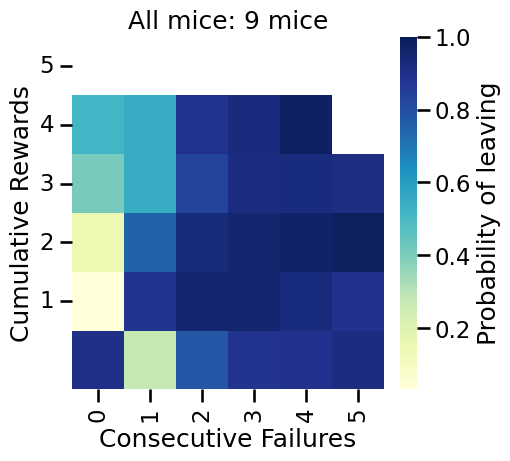

In [10]:
import matplotlib

fig, ax = plt.subplots(1, 1, figsize=(5, 4.5), constrained_layout=True, sharex=True, sharey=True)

# # Count number of samples per bin
# counts = final_df.groupby(['cumulative_rewards', 'consecutive_failures']).fraction_visited.count().unstack()

# Compute mean (probability) per bini
probs = final_df.groupby(['cumulative_rewards', 'consecutive_failures']).fraction_visited.mean().unstack()

# # Mask out bins with fewer than 5 samples
# probs[counts < 5] = np.nan

if variable == 'stop':
    plot = probs
    title = 'Probability of stopping'
    cmap = 'YlGnBu'
else:
    plot = 1 - probs
    title = 'Probability of leaving'
    cmap = 'YlGnBu'
    
plot = plot.astype(float)
plot = plot.fillna(np.nan)  # or use .fillna(0) if you prefer

last_hm = sns.heatmap(plot, ax=ax, cmap=cmap, cbar=True, vmax=vmax, cbar_kws={'label': title})
ax.invert_yaxis()
ax.set_ylabel('Cumulative Rewards')
ax.set_xlabel('Consecutive Failures')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
ax.set_xticklabels(ax.get_xticks().astype(int))
ax.set_yticklabels(ax.get_yticks().astype(int))
# Set ticks to be centered in the square
ax.set_yticks(np.arange(1, max_number, step) + 0.5, minor=False)
ax.set_xticks(np.arange(0, max_number, step) + 0.5, minor=False)
ax.set_xticklabels([str(x) for x in np.arange(0, max_number, step)])
ax.set_yticklabels([str(y) for y in np.arange(1, max_number, step)])
ax.tick_params(axis='x', labelbottom=True)
ax.tick_params(axis='y')
ax.set_title(f'All mice: {df.mouse.nunique()} mice')
ax.set_xlim(0, max_number-1)
ax.set_ylim(0, max_number-1)

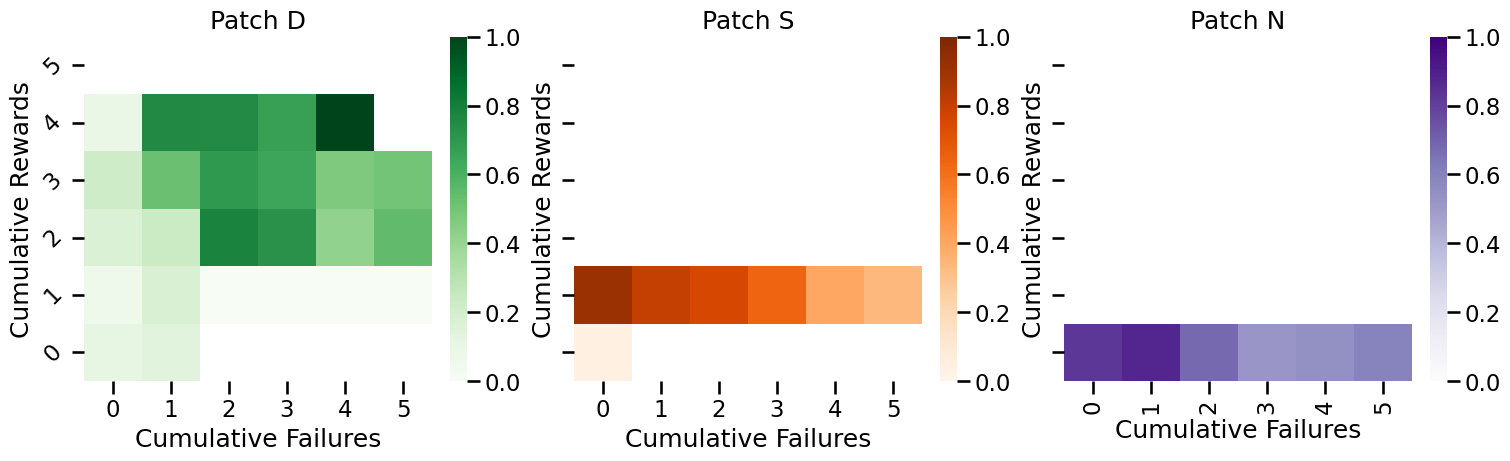

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True, sharex=True, sharey=True)

for ax, patch_label,colors in zip(axes.flatten(), ['D', 'S', 'N'], ['Greens', 'Oranges', 'Purples']):
    # Count number of samples per bin
    counts = df.loc[df.patch_label == patch_label].groupby(['cumulative_rewards', 'cumulative_failures']).is_choice.count().unstack()

    # Compute mean (probability) per bin
    probs = df.loc[df.patch_label == patch_label].groupby(['cumulative_rewards', 'cumulative_failures']).is_choice.mean().unstack()

    # Mask out bins with fewer than 5 samples
    # probs[counts < 5] = np.nan

    if variable == 'stop':
        plot = probs
        title = 'Probability of stopping'
    else:
        plot = 1 - probs
        title = 'Probability of leaving'
        
    plot = plot.astype(float)
    plot = plot.fillna(np.nan)  # or use .fillna(0) if you prefer
        
    last_hm = sns.heatmap(plot, ax=ax, cmap=colors, cbar=True, vmax=vmax)
    ax.invert_yaxis()
    ax.set_ylabel('Cumulative Rewards')
    ax.set_xlabel('Cumulative Failures')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    ax.set_xticklabels(ax.get_xticks().astype(int))
    ax.set_yticklabels(ax.get_yticks().astype(int))
    # Set ticks to be centered in the square
    ax.set_yticks(np.arange(0, max_number+1, step) + 0.5, minor=False)
    ax.set_xticks(np.arange(0, max_number, step) + 0.5, minor=False)
    ax.set_xticklabels([str(x) for x in np.arange(0, max_number, step)])
    ax.set_yticklabels([str(y) for y in np.arange(0, max_number+1, step)])
    ax.tick_params(axis='x', labelbottom=True)
    ax.tick_params(axis='y')
    ax.set_xlim(0, max_number-1)
    ax.set_title(f'Patch {patch_label}')
    ax.set_ylim(0, max_number-1)

    # cbar = fig.colorbar(last_hm.collections[0], ax=axes[:n_mice], orientation='vertical', fraction=0.02, pad=0.04)
    # cbar.set_label(title)

### **Number of sites visited per patch type across time**

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\tiffany.ona\\OneDrive - Allen Institute\\Documents\\VR foraging\\experiments\\batch 8 - reversals\\results\\average_site_number.pdf'

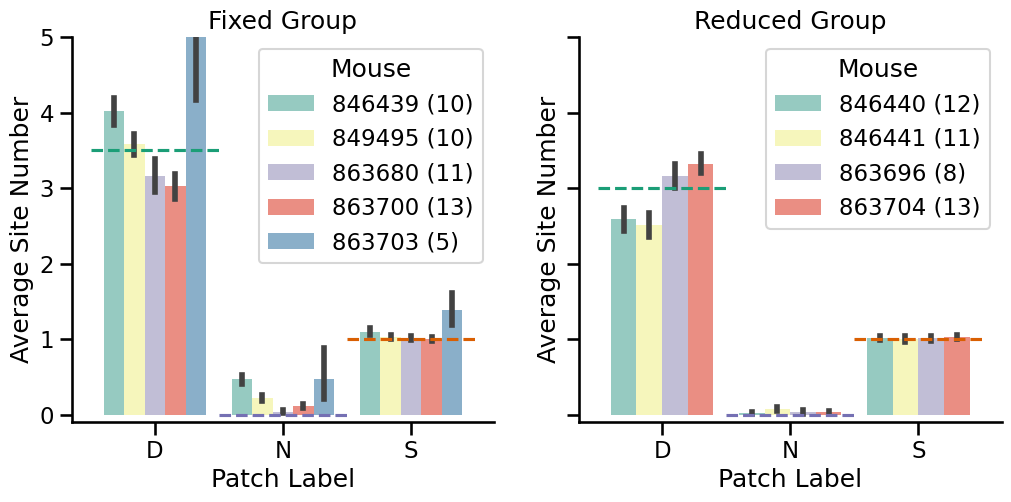

In [100]:
df = summary_df.groupby(['mouse', 'session', 'session_n', 'group', 'patch_label', 'patch_number']).agg({'site_number': 'max'}).reset_index()

# Compute number of sessions per mouse
sessions_per_mouse = df.groupby('mouse')['session'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, group in zip(axes, ['fixed', 'reduced']):
    sns.barplot(x='patch_label', y='site_number', hue='mouse',
                data=df.loc[df.group == group], palette='Set3', ax=ax)
    ax.set_title(group)
    ax.set_xlabel('Patch Label')
    ax.set_ylabel('Average Site Number')
    # Update legend labels to include session count
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [f"{mouse} ({sessions_per_mouse.get(mouse, 0)})" for mouse in labels]
    ax.legend(handles, new_labels, title='Mouse')
    ax.set_ylim(-0.1, 5)
    ax.hlines(y=0, xmin=0.5, xmax=1.5, color=color3, linestyle='--')
    ax.hlines(y=1, xmin=1.5, xmax=2.5, color=color1, linestyle='--')

    if group == 'fixed':
        ax.hlines(y=3.5, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
    else:
        ax.hlines(y=3, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
        
axes[0].set_title('Fixed Group')
axes[1].set_title('Reduced Group')
sns.despine()
fig.savefig(os.path.join(results_path, f'average_site_number.pdf'), dpi=300, bbox_inches='tight')

ValueError: Could not interpret value `site_number` for parameter `y`

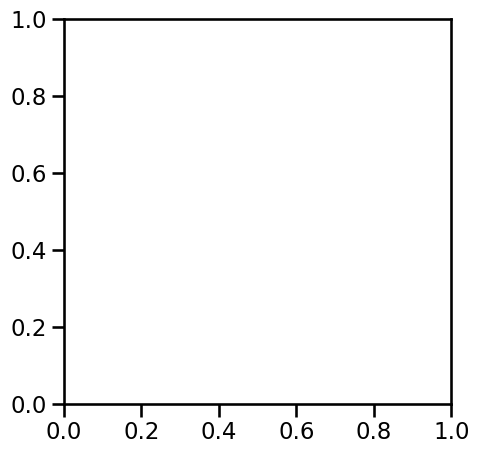

In [93]:
fig, ax = plt.subplots(figsize=(5,5))
sns.lineplot(data = df, x='session_n', y='site_number', hue='patch_label', style='group', errorbar=None, palette=color_dict_label, marker='o')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([28, 29, 30, 31, 32], labels=[f'{i}' for i in [0, 1, 2, 3, 4]])
plt.xlabel('Session Number')
plt.ylabel('Average stops')
sns.despine()
fig.savefig(os.path.join(results_path, f'mouse_average_site_number.svg'), dpi=300, bbox_inches='tight')

### **Leave before depletion**

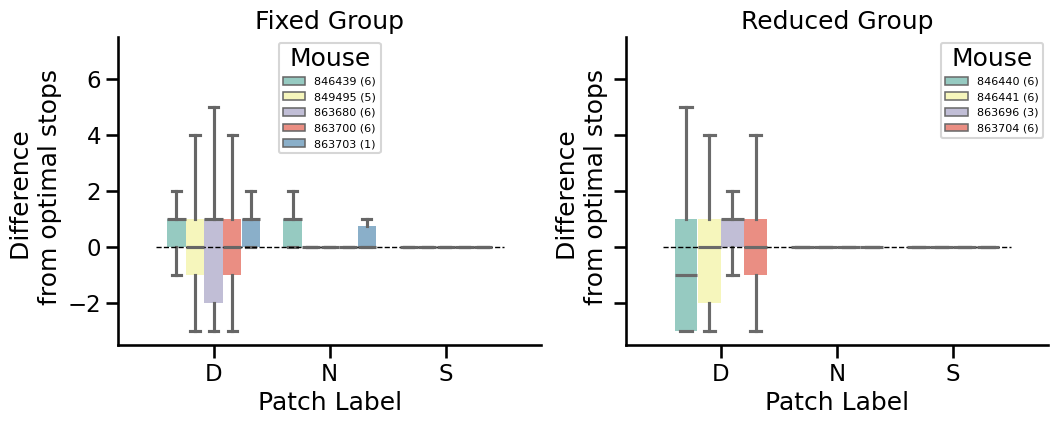

In [91]:
plot = summary_df.loc[summary_df.engaged == 1].groupby(['mouse', 'session', 'session_n', 'group', 'patch_label', 'patch_number']).agg({'excess_stops': 'max'}).reset_index()
# plot = plot.groupby(['mouse', 'session', 'session_n', 'group', 'patch_label']).agg({'excess_stops': 'mean'}).reset_index()

# Compute number of sessions per mouse
sessions_per_mouse = plot.loc[plot.group.isin(['reduced', 'fixed'])].groupby('mouse')['session'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, group in zip(axes, ['fixed', 'reduced']):
    sns.boxplot(x='patch_label', y='excess_stops', hue='mouse', fliersize=False,
                data=plot.loc[plot.group == group], palette='Set3', ax=ax, boxprops=dict(linewidth=0))
    ax.set_title(group)
    ax.set_xlabel('Patch Label')
    ax.set_ylabel('Difference \n from optimal stops')
    # Update legend labels to include session count
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [f"{mouse} ({sessions_per_mouse.get(mouse, 0)})" for mouse in labels]
    ax.legend(handles, new_labels, title='Mouse', fontsize=8)
    # ax.set_ylim(-2, 1.5)
    ax.hlines(y=0, xmin=-0.5, xmax=2.5, color='k', linestyle='--', linewidth=1)
    # ax.hlines(y=1, xmin=1.5, xmax=2.5, color=color1, linestyle='--')

    # if group == 'fixed':
    #     ax.hlines(y=3.5, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
    # else:
    #     ax.hlines(y=3, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
        
axes[0].set_title('Fixed Group')
axes[1].set_title('Reduced Group')
sns.despine()
fig.savefig(os.path.join(results_path, f'consecutive_failures.pdf'), dpi=300, bbox_inches='tight')

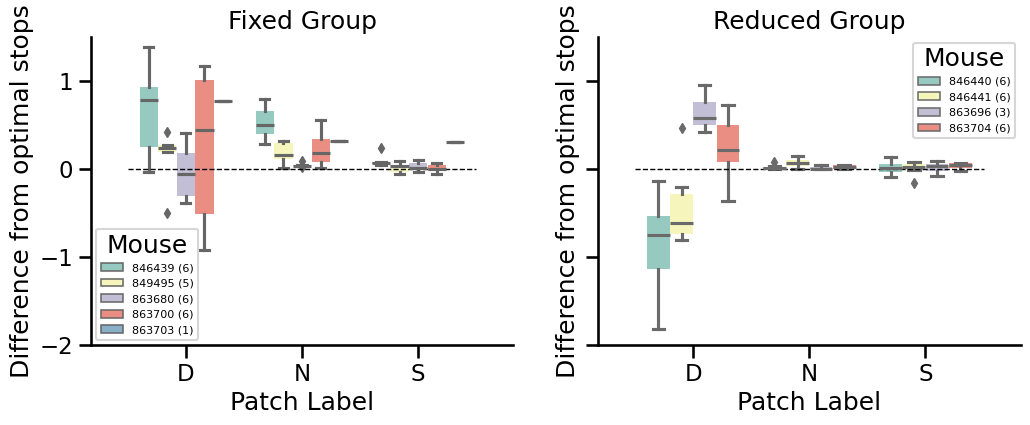

In [92]:
plot = summary_df.loc[summary_df.engaged == 1].groupby(['mouse', 'session', 'session_n', 'group', 'patch_label', 'patch_number']).agg({'excess_stops': 'max'}).reset_index()
plot = plot.groupby(['mouse', 'session', 'session_n', 'group', 'patch_label']).agg({'excess_stops': 'mean'}).reset_index()

# Compute number of sessions per mouse
sessions_per_mouse = plot.loc[plot.group.isin(['reduced', 'fixed'])].groupby('mouse')['session'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

for ax, group in zip(axes, ['fixed', 'reduced']):
    sns.boxplot(x='patch_label', y='excess_stops', hue='mouse',
                data=plot.loc[plot.group == group], palette='Set3', ax=ax, boxprops=dict(linewidth=0))
    ax.set_title(group)
    ax.set_xlabel('Patch Label')
    ax.set_ylabel('Difference from optimal stops')
    # Update legend labels to include session count
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [f"{mouse} ({sessions_per_mouse.get(mouse, 0)})" for mouse in labels]
    ax.legend(handles, new_labels, title='Mouse', fontsize=8)
    ax.set_ylim(-2, 1.5)
    ax.hlines(y=0, xmin=-0.5, xmax=2.5, color='k', linestyle='--', linewidth=1)
    # ax.hlines(y=1, xmin=1.5, xmax=2.5, color=color1, linestyle='--')

    # if group == 'fixed':
    #     ax.hlines(y=3.5, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
    # else:
    #     ax.hlines(y=3, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
        
axes[0].set_title('Fixed Group')
axes[1].set_title('Reduced Group')
sns.despine()
fig.savefig(os.path.join(results_path, f'consecutive_failures.pdf'), dpi=300, bbox_inches='tight')

### **Number of consecutive failures per patch type across time**

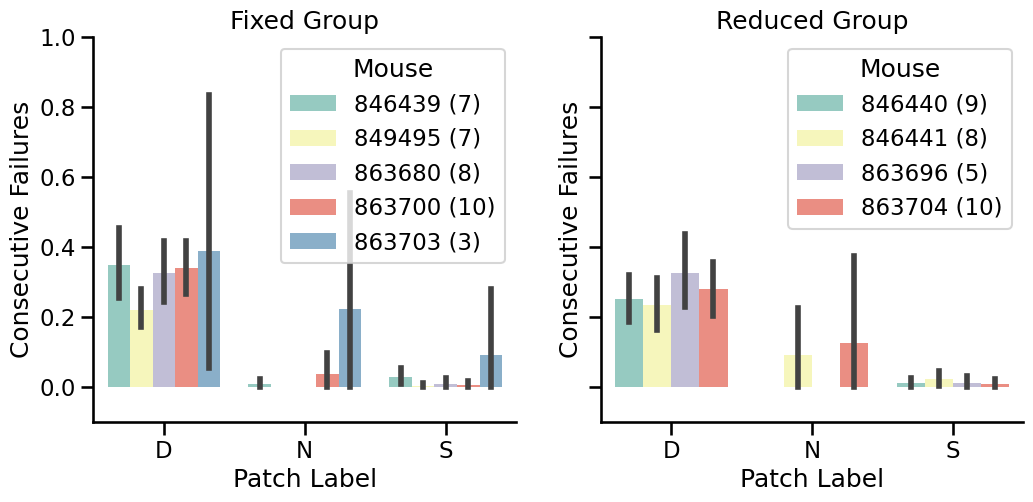

In [16]:
df = summary_df.loc[summary_df.last_visit == 1].groupby(['mouse', 'session', 'session_n', 'group', 'patch_label', 'patch_number']).agg({'consecutive_failures': 'max'}).reset_index()

# Compute number of sessions per mouse
sessions_per_mouse = df.groupby('mouse')['session'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, group in zip(axes, ['fixed', 'reduced']):
    sns.barplot(x='patch_label', y='consecutive_failures', hue='mouse',
                data=df.loc[df.group == group], palette='Set3', ax=ax)
    ax.set_title(group)
    ax.set_xlabel('Patch Label')
    ax.set_ylabel('Consecutive Failures')
    # Update legend labels to include session count
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [f"{mouse} ({sessions_per_mouse.get(mouse, 0)})" for mouse in labels]
    ax.legend(handles, new_labels, title='Mouse')
    ax.set_ylim(-0.1, 1)
    # ax.hlines(y=0, xmin=0.5, xmax=1.5, color=color3, linestyle='--')
    # ax.hlines(y=1, xmin=1.5, xmax=2.5, color=color1, linestyle='--')

    # if group == 'fixed':
    #     ax.hlines(y=3.5, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
    # else:
    #     ax.hlines(y=3, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
        
axes[0].set_title('Fixed Group')
axes[1].set_title('Reduced Group')
sns.despine()
fig.savefig(os.path.join(results_path, f'consecutive_failures.pdf'), dpi=300, bbox_inches='tight')

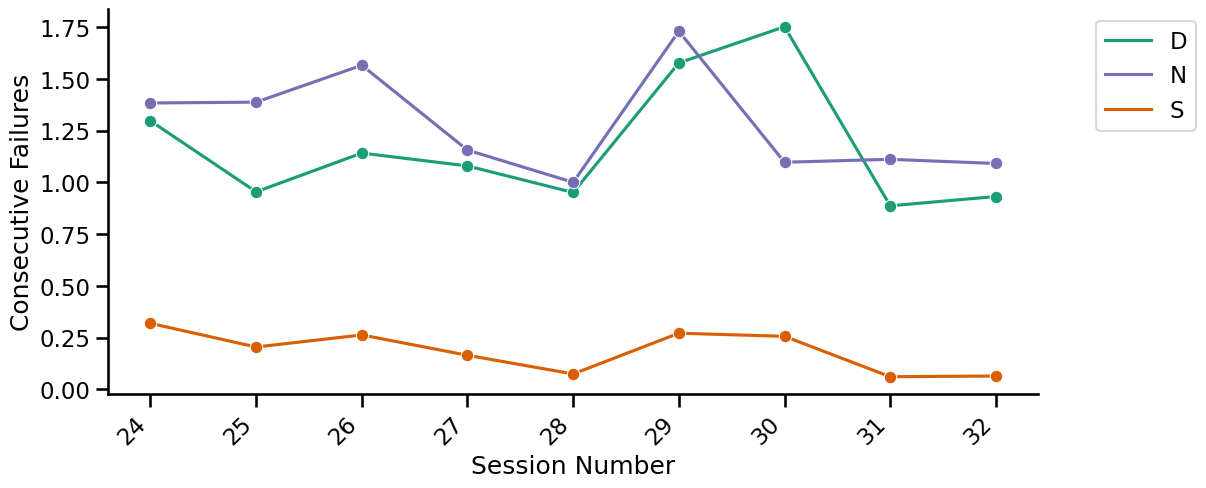

In [100]:
fig, ax = plt.subplots(figsize=(12, 5))
df = summary_df.loc[summary_df.site_number > 0].groupby(['mouse', 'session_n', 'patch_label','patch_number']).agg({'consecutive_failures': 'max'}).reset_index()
sns.lineplot(data = df, x='session_n', y='consecutive_failures', hue='patch_label', errorbar=None, palette=color_dict_label, marker='o')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.ylabel('Consecutive Failures')
plt.xlabel('Session Number')
sns.despine()
fig.savefig(os.path.join(results_path, f'mouse_consecutive_failures.svg'), dpi=300, bbox_inches='tight')

### **Total visited patches**

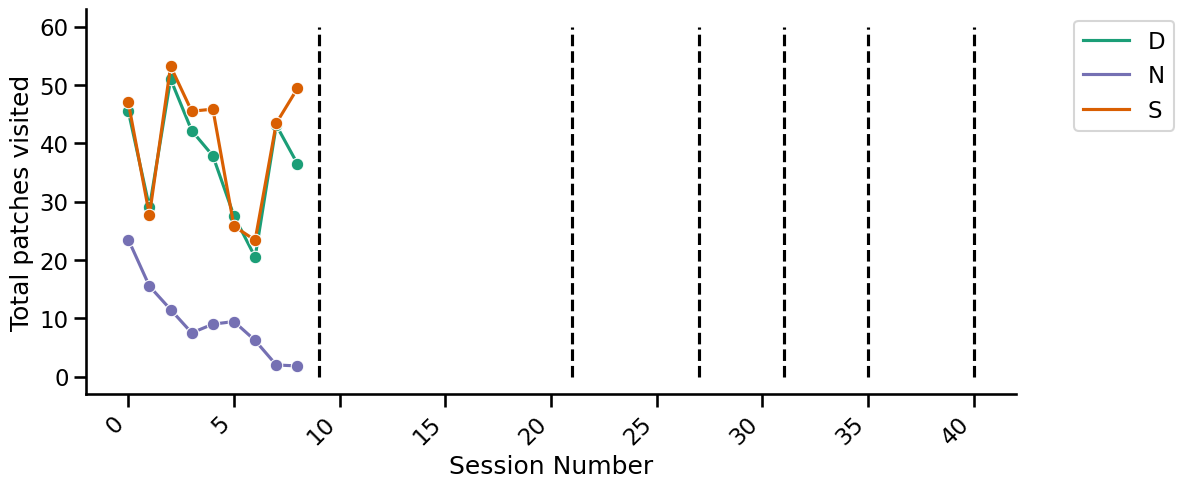

In [101]:
fig, ax = plt.subplots(figsize=(12, 5))
df = sum_df.loc[sum_df.mouse != 754579].groupby(['mouse', 'session_n', 'patch_label']).agg({'visited': 'mean'}).reset_index()
sum_df.sort_values(by=['session_n'], inplace=True)
plt.vlines(x=9, ymin=0, ymax=60, color='k', linestyle='--')
plt.vlines(x=21, ymin=0, ymax=60, color='k', linestyle='--')
plt.vlines(x=27, ymin=0, ymax=60, color='k', linestyle='--')
plt.vlines(x=31, ymin=0, ymax=60, color='k', linestyle='--')
plt.vlines(x=35, ymin=0, ymax=60, color='k', linestyle='--')
plt.vlines(x=40, ymin=0, ymax=60, color='k', linestyle='--')

sns.lineplot(data = df, x='session_n', y='visited', hue='patch_label', palette=color_dict_label, errorbar=None, marker='o')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Total patches visited')
plt.xlabel('Session Number')
sns.despine()
fig.savefig(os.path.join(results_path, f'patch_number.svg'), dpi=300, bbox_inches='tight')

In [ ]:
from scipy.stats import sem  # standard error of the mean

sessions = [25, 29, 31]  # Define the sessions of interest
# Step 1: Prepare the data
df = sum_df.loc[
    sum_df.session_n.isin(sessions)
].groupby(['mouse', 'session', 'session_n', 's_patch_label', 'patch_number']).agg(
    {'visited': 'mean'}
).reset_index()

# Step 2: Aggregate to compute mean and SEM
agg_df = df.groupby(['s_patch_label', 'session_n']).agg(
    mean_fraction=('visited', 'mean'),
    sem_fraction=('visited', sem)
).reset_index()

# Step 3: Set up variables
session_label_map = {25: 'Before', 29: 'Stop duration', 31: 'Distance'}
hatch_dict = {'Before': '', 'Stop duration': '///', 'Distance': 'xx'}
labels = sorted(agg_df['s_patch_label'].unique())
x = np.arange(len(labels))  # x locations for s_patch_label
width = 0.25  # width of each bar

# You should already have this defined:
# color_dict_label = {'A': 'royalblue', 'B': 'tomato', 'C': 'seagreen'}  # example

# Step 4: Plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, session in enumerate(sessions):
    session_label = session_label_map[session]
    subset = agg_df[agg_df['session_n'] == session]

    heights = [
        subset[subset['s_patch_label'] == label]['mean_fraction'].values[0]
        if label in subset['s_patch_label'].values else 0
        for label in labels
    ]
    errors = [
        subset[subset['s_patch_label'] == label]['sem_fraction'].values[0]
        if label in subset['s_patch_label'].values else 0
        for label in labels
    ]

    ax.bar(
        x + i * width - width/2,
        heights,
        yerr=errors,
        capsize=5,
        width=width,
        color=[color_dict_label[label] for label in labels],
        hatch=hatch_dict[session_label],
        edgecolor='black',
        label=session_label
    )

# Step 5: Labels and legend
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Patch label")
ax.set_ylabel("Total patches visited")
ax.legend(title="Session", bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(results_path, f'total_patches_bars_with_sem.svg'), dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Define sessions, label mapping, hatches
sessions = [25, 29, 31]
session_label_map = {25: 'Before', 29: 'Stop duration', 31: 'Distance'}
hatch_dict = {'Before': '', 'Stop duration': '///', 'Distance': 'xx'}

# Layout: how many columns of plots?
ncols = 4
nrows = int(np.ceil(len(mouse_list) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*4), sharey=True)
axes = axes.flatten()

for idx, mouse in enumerate(mouse_list):
    ax = axes[idx]
    sum_df_mouse = sum_df[sum_df.mouse == mouse]
    if sum_df_mouse.empty:
        ax.set_visible(False)
        continue

    # Step 1: Prepare the data
    df = sum_df_mouse[sum_df_mouse.session_n.isin(sessions)].groupby(
        ['mouse', 'session', 'session_n', 's_patch_label', 'patch_number']
    ).agg({'visited': 'mean'}).reset_index()

    # Step 2: Mean and SEM
    agg_df = df.groupby(['s_patch_label', 'session_n']).agg(
        mean_fraction=('visited', 'mean'),
        sem_fraction=('visited', sem)
    ).reset_index()

    labels = sorted(agg_df['s_patch_label'].unique())
    x = np.arange(len(labels))
    width = 0.25

    for i, session in enumerate(sessions):
        session_label = session_label_map[session]
        subset = agg_df[agg_df.session_n == session]

        heights = [
            subset[subset['s_patch_label'] == label]['mean_fraction'].values[0]
            if label in subset['s_patch_label'].values else 0
            for label in labels
        ]
        errors = [
            subset[subset['s_patch_label'] == label]['sem_fraction'].values[0]
            if label in subset['s_patch_label'].values else 0
            for label in labels
        ]

        ax.bar(
            x + i * width - width / 2,
            heights,
            yerr=errors,
            capsize=5,
            width=width,
            color=[color_dict_label[label] for label in labels],
            hatch=hatch_dict[session_label],
            edgecolor='black',
            label=session_label
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f"Mouse {mouse}")
    if idx % ncols == 0:
        ax.set_ylabel("Total patches visited")
    if idx // ncols == nrows - 1:
        ax.set_xlabel("Patch label")

    ax.legend(title="Session", fontsize=8, title_fontsize=9, loc='upper right')
    sns.despine(ax=ax)

# Hide any extra axes
for i in range(len(mouse_list), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(results_path, 'total_patches_grid_per_mouse.svg'), dpi=300, bbox_inches='tight')
plt.show()


### **Fraction of visited per patch type across time**

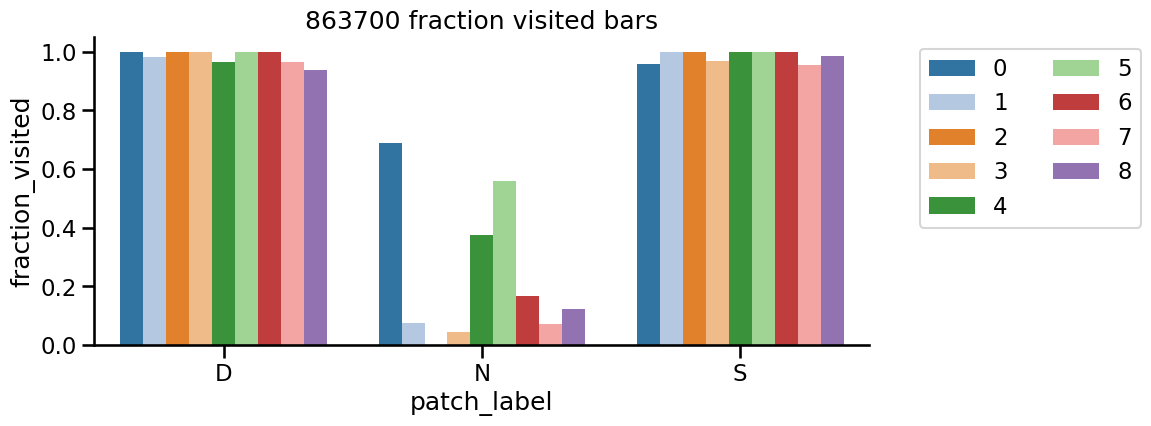

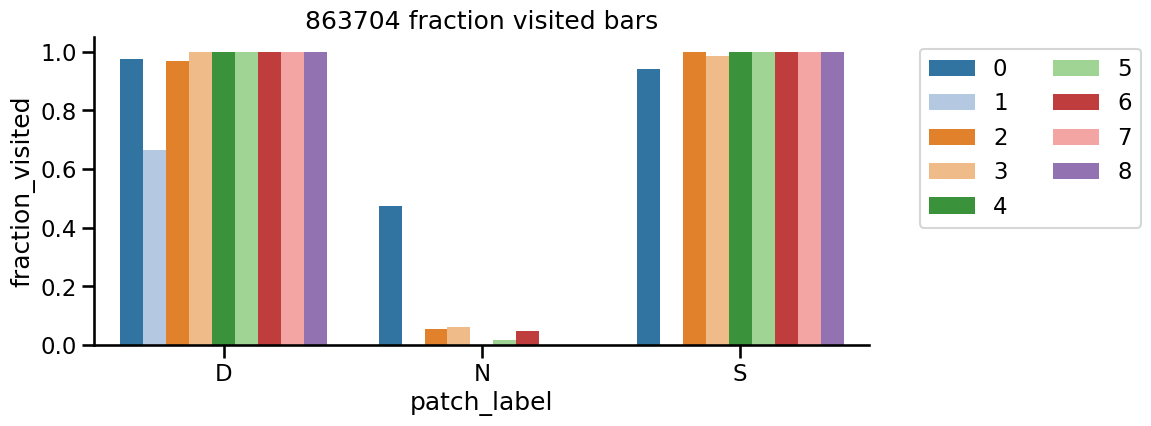

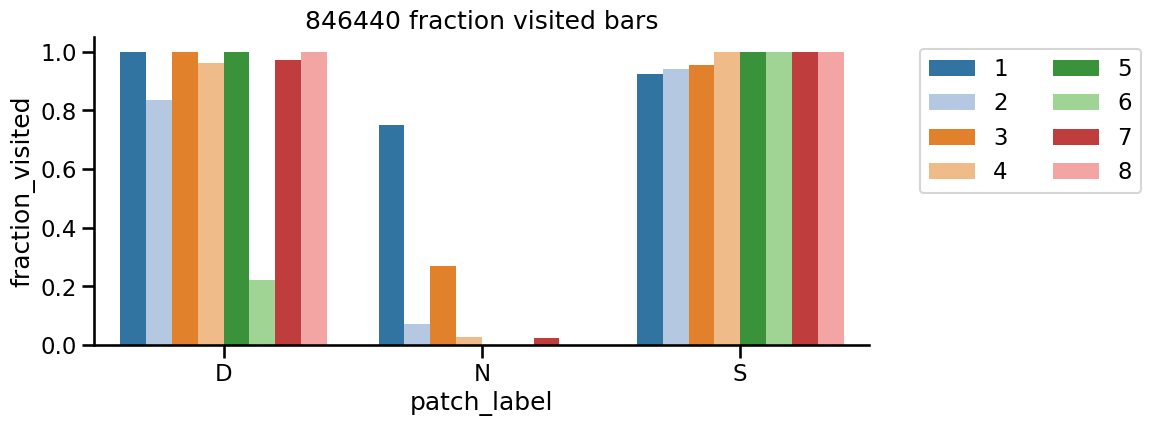

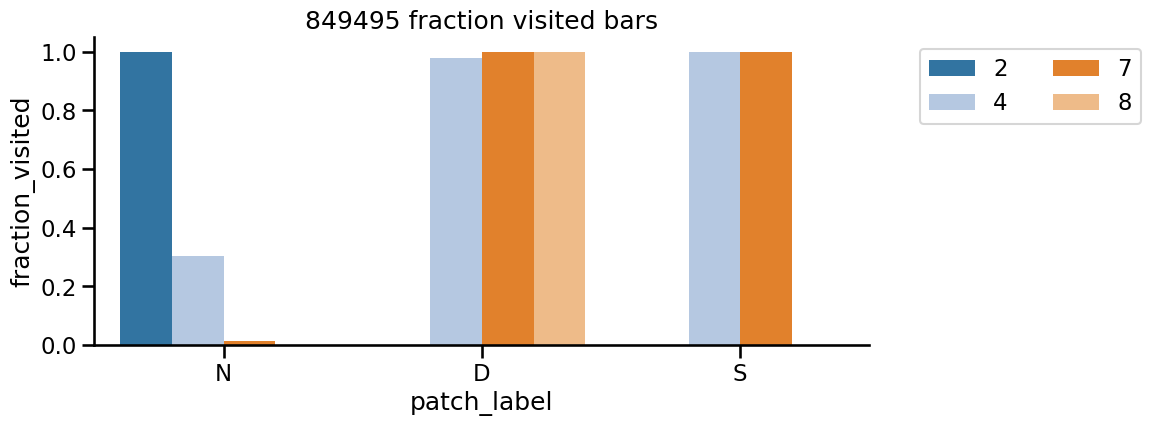

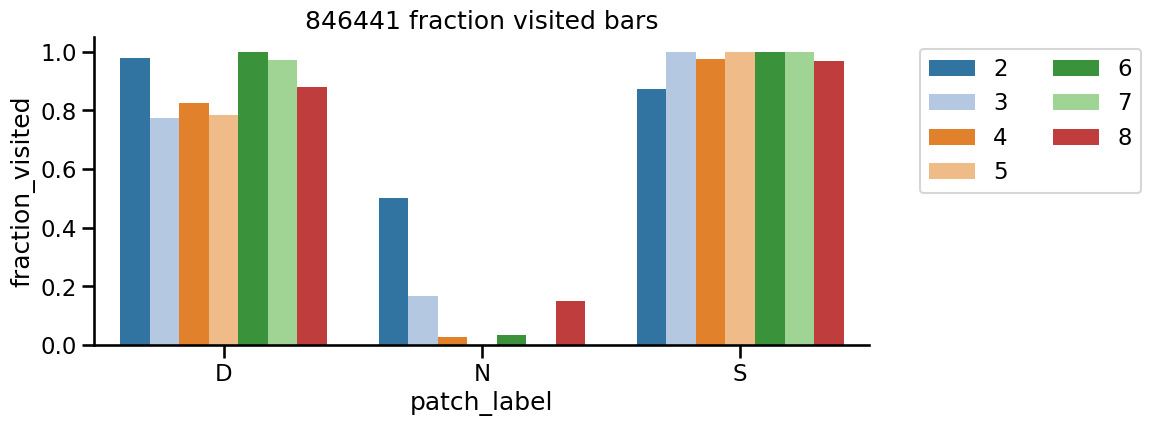

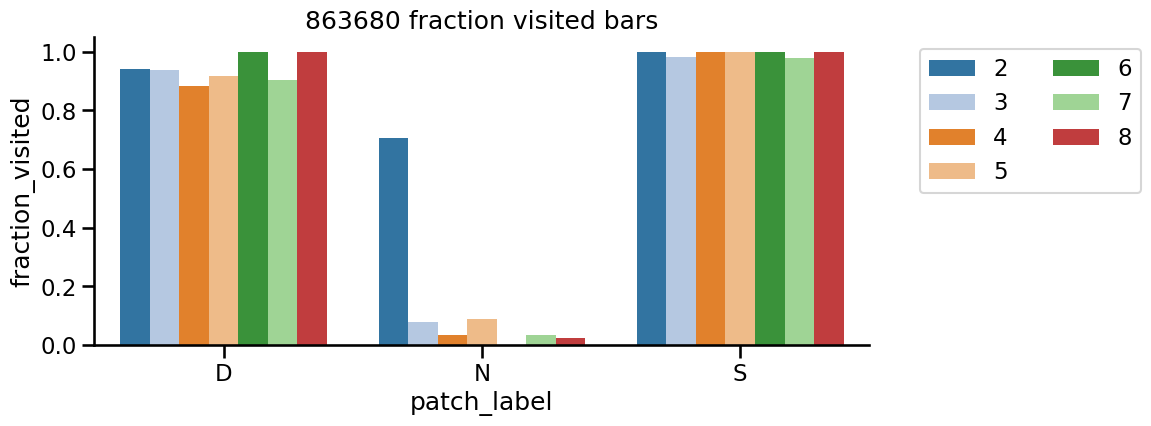

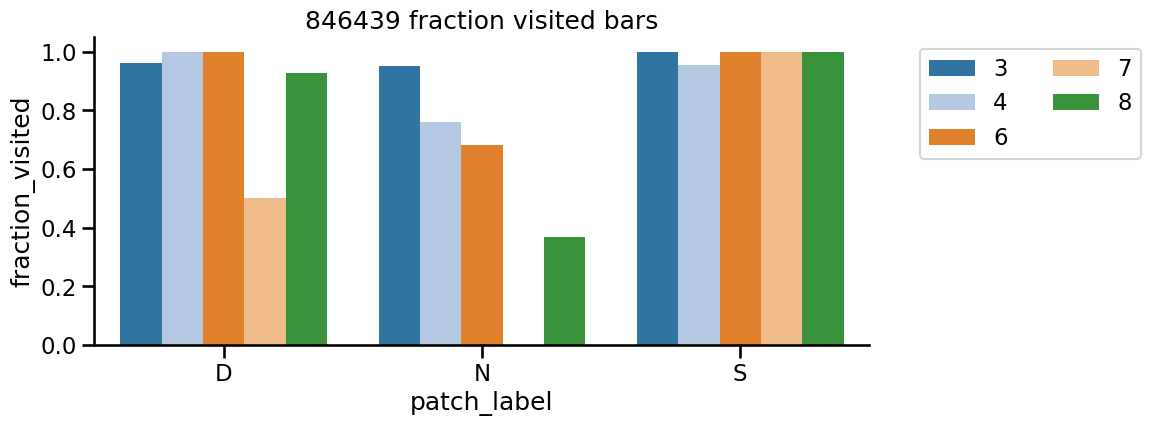

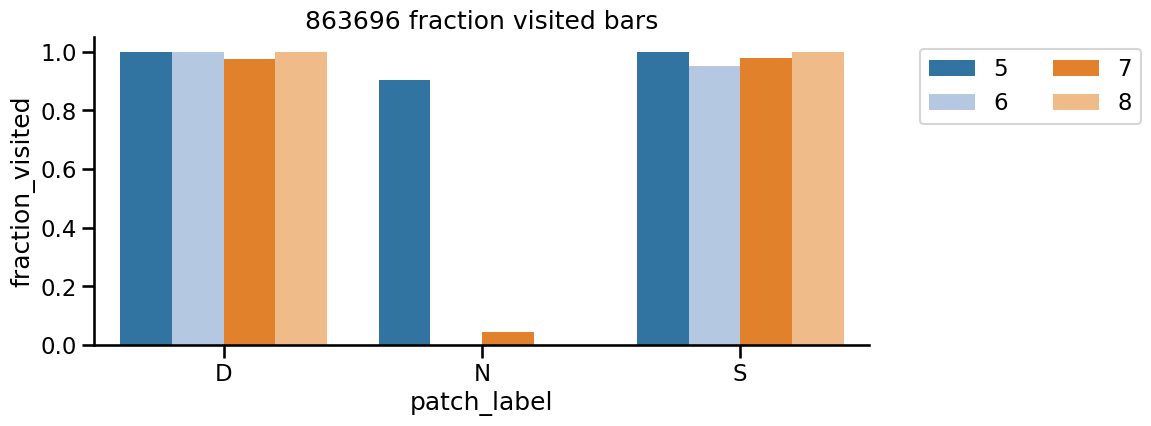

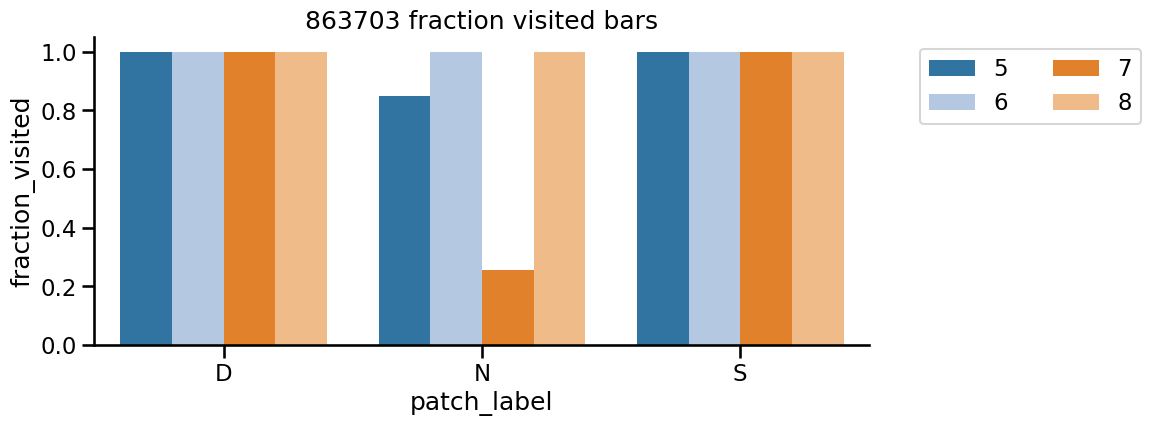

In [144]:
sum_df.sort_values(by=['session'], inplace=True)
df = sum_df.groupby(['mouse', 'session_n', 'patch_label']).agg({'fraction_visited': 'mean'}).reset_index()
for mouse in sum_df.mouse.unique():
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x='patch_label', y='fraction_visited', hue='session_n', data=df.loc[df.mouse==mouse], palette='tab20', errorbar=None)  
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    sns.despine()
    plt.title(f'{mouse} fraction visited bars')
    plt.show()
    # fig.savefig(os.path.join(results_path, f'fraction_visited_bars.pdf'), dpi=300, bbox_inches='tight')

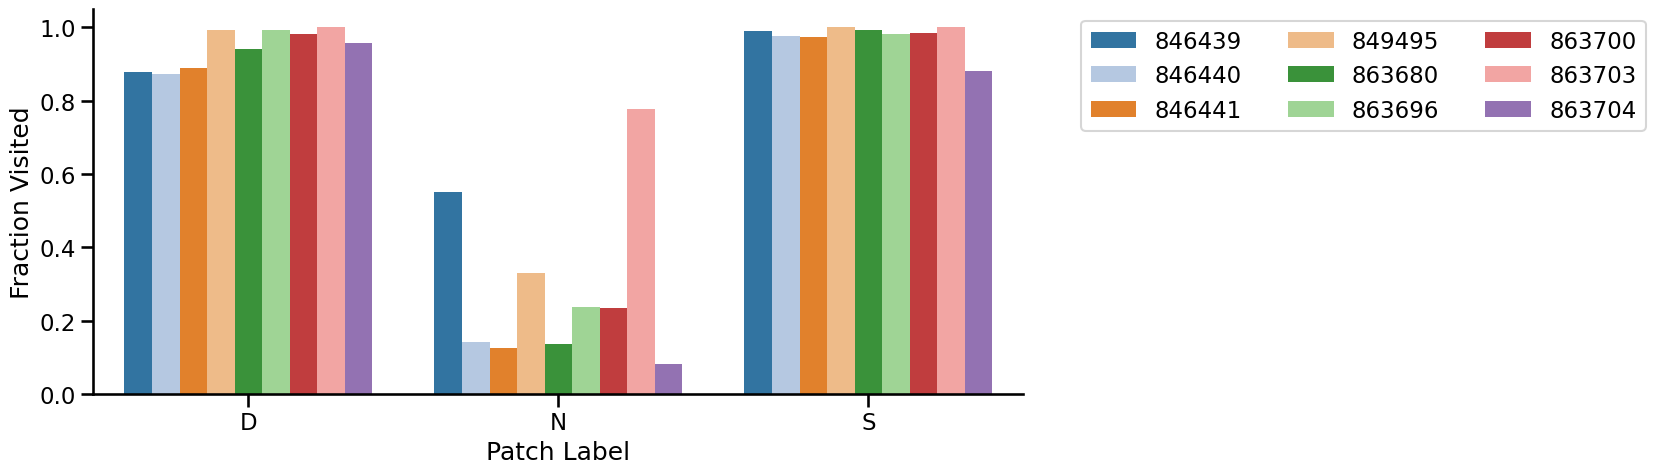

In [147]:
fig, ax = plt.subplots(figsize=(12, 5))
sum_df.sort_values(by=['session'], inplace=True)
df = sum_df.groupby(['mouse', 'session_n', 'patch_label']).agg({'fraction_visited': 'mean'}).reset_index()
sns.barplot(x='patch_label', y='fraction_visited', hue='mouse', data=df, palette='tab20', errorbar=None)  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=3)
sns.despine()
plt.xlabel('Patch Label')
plt.ylabel('Fraction Visited')
fig.savefig(os.path.join(results_path, f'fraction_visited_bars.svg'), dpi=300, bbox_inches='tight')

AttributeError: 'DataFrame' object has no attribute 'group'

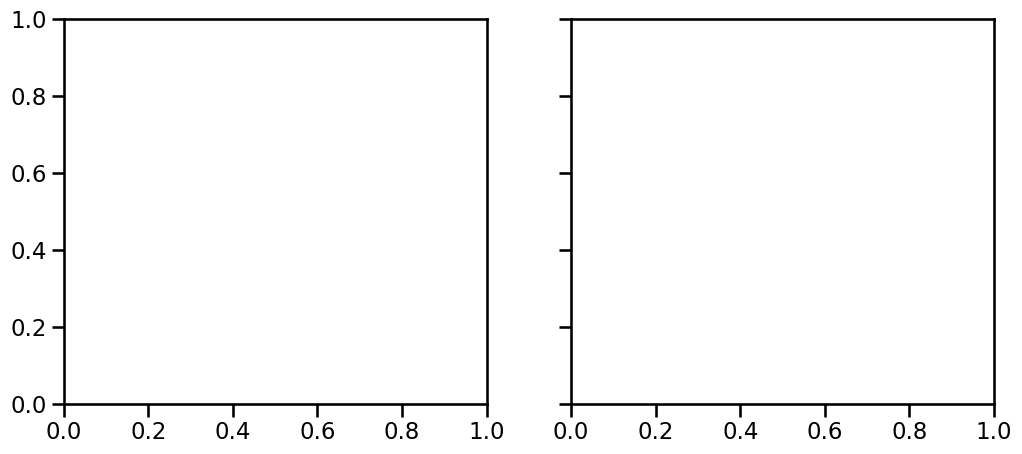

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, group in zip(axes, ['fixed', 'reduced']):
    sns.barplot(x='patch_label', y='fraction_visited', hue='mouse',
                data=df.loc[df.group == group], palette='Set3', ax=ax)
    ax.set_title(group)
    ax.set_xlabel('Patch Label')
    ax.set_ylabel('Consecutive Failures')
    # Update legend labels to include session count
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [f"{mouse} ({sessions_per_mouse.get(mouse, 0)})" for mouse in labels]
    ax.legend(handles, new_labels, title='Mouse')
    ax.set_ylim(-0.1, 1)
    # ax.hlines(y=0, xmin=0.5, xmax=1.5, color=color3, linestyle='--')
    # ax.hlines(y=1, xmin=1.5, xmax=2.5, color=color1, linestyle='--')

    # if group == 'fixed':
    #     ax.hlines(y=3.5, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
    # else:
    #     ax.hlines(y=3, xmin=-0.5, xmax=0.5, color=color2, linestyle='--')
        
axes[0].set_title('Fixed Group')
axes[1].set_title('Reduced Group')
sns.despine()
fig.savefig(os.path.join(results_path, f'consecutive_failures.pdf'), dpi=300, bbox_inches='tight')

### **Look at stops per odor site**

In [151]:
patch_df = summary_df.groupby(['mouse','group','patch_label']).agg({'patch_number': 'nunique'}).reset_index()
final_df = pd.merge(summary_df, patch_df, on=['mouse','group','patch_label'], how='left', suffixes=('', '_attempted'))
final_df = final_df.groupby(['mouse', 'site_number', 'group', 'patch_label']).agg({'patch_number': 'nunique','patch_number_attempted': 'mean'}).reset_index()
final_df['fraction_visited'] = final_df['patch_number'] / final_df['patch_number_attempted']

# Remove rows where site_number is 0 so everything is looking at stops
new_df = final_df.loc[final_df.site_number != 0]
# new_df = final_df

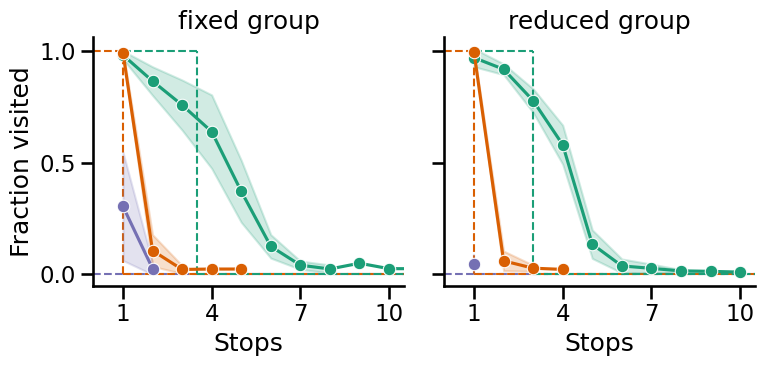

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
# Define the two levels for the threshold line
high_level = 1.0   # adjust to your desired high value
low_level = 0.0   # adjust to your desired low value

for ax, group in zip(axes.flatten(), ['fixed', 'reduced']):
    sns.lineplot(data=new_df.loc[new_df.group == group], x='site_number', y='fraction_visited', 
                hue='patch_label', ci='sd', ax=ax, legend=False, palette=color_dict_label, marker='o')
    ax.set_xlim(0, 10.5)
    ax.set_title(f'{group} group')
    ax.set_xlabel('Stops')
    ax.set_ylabel('Fraction visited')
    ax.set_xticks(np.arange(1, 11, 3))
    ax.set_yticks(np.arange(0, 1.1, 0.5))
    ax.plot([0, 0], [high_level, high_level], color=color3, linestyle='--', linewidth=1.5, zorder=0)
    ax.plot([0, 10.5], [low_level, low_level], color=color3, linestyle='--', linewidth=1.5, zorder=0)
    ax.vlines(x=0, ymin=low_level, ymax=high_level, color=color3, linestyle='--', linewidth=1.5, zorder=0)
    
    ax.plot([0.0, 1], [high_level, high_level], color=color1, linestyle='--', linewidth=1.5, zorder=0)
    ax.plot([1, 10.5], [low_level, low_level], color=color1, linestyle='--', linewidth=1.5, zorder=0)
    ax.vlines(x=1, ymin=low_level, ymax=high_level, color=color1, linestyle='--', linewidth=1.5, zorder=0)
    
    if group == 'fixed': 
        # Dashed threshold line: high for stops 1-4, low afterwards
        ax.plot([1, 3.5], [high_level, high_level], color=color2, linestyle='--', linewidth=1.5, zorder=0)
        ax.plot([3.5, 10.5], [low_level, low_level], color=color2, linestyle='--', linewidth=1.5, zorder=0)
        ax.vlines(x=3.5, ymin=low_level, ymax=high_level, color=color2, linestyle='--', linewidth=1.5, zorder=0)
    else:
        # Dashed threshold line: high for stops 1-3, low afterwards
        ax.plot([1, 3], [high_level, high_level], color=color2, linestyle='--', linewidth=1.5, zorder=0)
        ax.plot([3, 10.5], [low_level, low_level], color=color2, linestyle='--', linewidth=1.5, zorder=0)
        ax.vlines(x=3, ymin=low_level, ymax=high_level, color=color2, linestyle='--', linewidth=1.5, zorder=0)

sns.despine()
plt.tight_layout()
fig.savefig(os.path.join(results_path, f'fraction_visited_vs_stops_all_mice.pdf'), dpi=300, bbox_inches='tight')

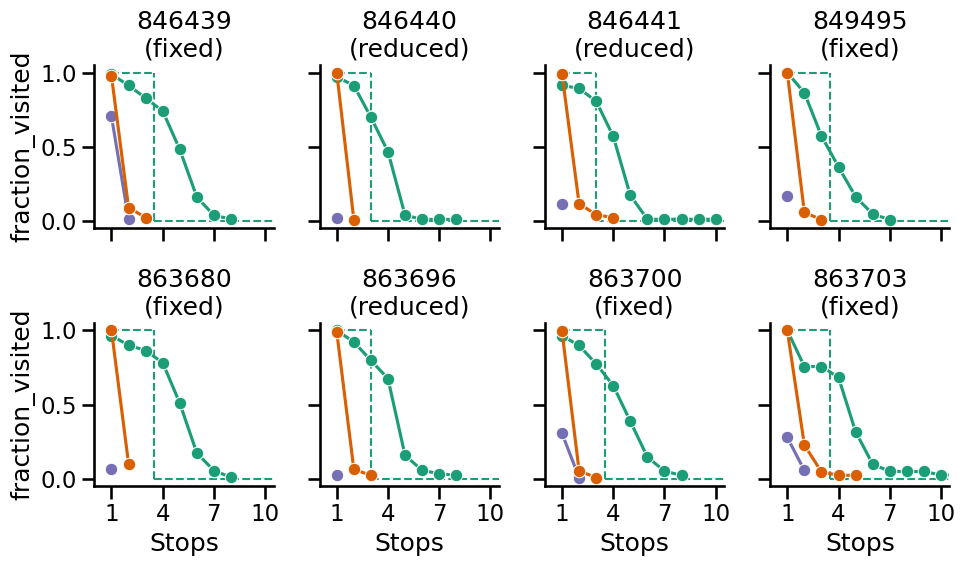

In [176]:
mice = new_df['mouse'].unique()
n_mice = len(mice)

fig, axes = plt.subplots(2, 4, figsize=(10, 6), sharex=True, sharey=True)

high_level = 1.0
low_level = 0.0


for ax, mouse in zip(axes.flatten(), mice):
    mouse_df = new_df.loc[(new_df.mouse == mouse) & (new_df.group.isin(['fixed', 'reduced']))]
    group = mouse_df['group'].iloc[0]  # each mouse belongs to one group
    
    sns.lineplot(data=mouse_df, x='site_number', y='fraction_visited',
                hue='patch_label', ci='sd', ax=ax, legend=False,
                palette=color_dict_label, marker='o')

    # Threshold line depends on group
    cutoff = 3.5 if group == 'fixed' else 3.0
    ax.plot([1, cutoff], [high_level, high_level], color=color2, linestyle='--', linewidth=1.5, zorder=0)
    ax.plot([cutoff, 10.5], [low_level, low_level], color=color2, linestyle='--', linewidth=1.5, zorder=0)
    ax.vlines(x=cutoff, ymin=low_level, ymax=high_level, color=color2, linestyle='--', linewidth=1.5, zorder=0)

    ax.set_xlim(0, 10.5)
    ax.set_title(f'{mouse}\n({group})')
    ax.set_xlabel('Stops')
    # ax.set_ylabel('Fraction visited' if ax == axes[0] else '')
    ax.set_xticks(np.arange(1, 11, 3))
    ax.set_yticks(np.arange(0, 1.1, 0.5))

sns.despine()
plt.tight_layout()
fig.savefig(os.path.join(results_path, f'fraction_visited_vs_stops_per_mouse.pdf'), dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.lines as mlines

session_1 = '2025-05-26'
session_2 = '2025-05-28'

patch_df = summary_df.groupby(['mouse','session', 'patch_label']).agg({'patch_number': 'nunique'}).reset_index()
final_df = pd.merge(summary_df, patch_df, on=['mouse', 'session','patch_label'], how='left', suffixes=('', '_attempted'))
final_df = final_df.groupby(['mouse', 'site_number', 'session','patch_label']).agg({'patch_number': 'nunique','patch_number_attempted': 'mean'}).reset_index()
final_df['fraction_visited'] = final_df['patch_number'] / final_df['patch_number_attempted']

hue_handles = None
# Remove rows where site_number is 0 so everything is looking at stops
new_df = final_df.loc[final_df.site_number != 0]
fig, axes = plt.subplots(len(new_df.mouse.unique()), 3, figsize=(10, 20))

for ax, mouse in zip(axes.flatten(), new_df.mouse.unique()):
    plot = sns.lineplot(
        data=new_df.loc[(new_df.mouse == mouse)],
        x='site_number',
        y='fraction_visited',
        hue='patch_label',
        ax=ax,
        legend=False,
        palette=color_dict_label,
        alpha=0.8
    )

    if hue_handles is None:
        handles, labels = ax.get_legend_handles_labels()
        hue_handles = (handles, labels)
        
    ax.set_xlim(0, 10)
    ax.set_title(f'Mouse {mouse}')
    ax.set_xlabel('Odor site number')
    ax.set_ylabel('Fraction visited')
    ax.set_xticks(np.arange(1, 11, 3))
    ax.set_yticks(np.arange(0, 1.1, 0.5))
    sns.despine()


# Create session legend manually
session_legend = [
    mlines.Line2D([], [], color='gray', marker='s', linestyle=':', label=session_1),
    mlines.Line2D([], [], color='gray', marker='o', linestyle='-', label=session_2)
]

# Create hue legend from the saved handles
hue_handles_list = hue_handles[0]
hue_labels = hue_handles[1]

# Combine all legends into one
all_handles = session_legend + hue_handles_list
all_labels = [h.get_label() for h in session_legend] + hue_labels

# Place the legend outside the subplots
fig.legend(
    handles=all_handles,
    labels=all_labels,
    loc='upper center',
    ncol=5,
    bbox_to_anchor=(0.5, 1.02)
)
plt.tight_layout()

# fig.savefig(os.path.join(results_path, f'fraction_visited_by_mouse_{session}.pdf'), dpi=300, bbox_inches='tight')

In [ ]:
patch_df = summary_df.groupby(['mouse','session', 's_patch_label']).agg({'patch_number': 'nunique'}).reset_index()
final_df = pd.merge(summary_df, patch_df, on=['mouse', 'session','s_patch_label'], how='left', suffixes=('', '_attempted'))
final_df = final_df.groupby(['mouse', 'site_number', 'session','s_patch_label']).agg({'patch_number': 'nunique','patch_number_attempted': 'mean'}).reset_index()
final_df['fraction_visited'] = final_df['patch_number'] / final_df['patch_number_attempted']

# Remove rows where site_number is 0 so everything is looking at stops
new_df = final_df.loc[final_df.site_number != 0]

for session in summary_df.session.unique():
    session_df = new_df.loc[new_df.session == session]
    fig, axes = plt.subplots(5, 3, figsize=(12, 20))
    for ax, mouse in zip(axes.flatten(), session_df.mouse.unique()):
        sns.lineplot(
            data=session_df.loc[(session_df.mouse == mouse)],
            x='site_number',
            y='fraction_visited',
            hue='s_patch_label',
            ax=ax,
            legend=False,
            palette=color_dict_label,
            marker='o'
        )

        ax.set_xlim(0, 10)
        ax.set_title(f'Mouse {mouse}')
        ax.set_xlabel('Odor site number')
        ax.set_ylabel('Fraction visited')
        ax.set_xticks(np.arange(1, 11, 3))
        ax.set_yticks(np.arange(0, 1.1, 0.5))
        sns.despine()


    plt.tight_layout()
    fig.savefig(os.path.join(results_path, f'fraction_visited_by_mouse_{session}.pdf'), dpi=300, bbox_inches='tight')